In [1]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\minha\Desktop\global-fixed-income-strategy\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


# 01. Fixed Income Data Pipeline

This notebook builds and validates the market dataset used in the Global Fixed Income Strategy & Portfolio Research project.

## Data Scope

**Rates**
- U.S. Treasury 2Y, 5Y, 10Y, 30Y
- 2s10s and 5s30s yield-curve slopes

**Credit**
- Moody's Baa corporate spread relative to the 10-year Treasury (BAA10Y)

**Investable Assets**
- SHY
- IEF
- TLT
- LQD
- HYG

**Backtest Sample**
- January 2008 to July 2026

Daily observations are retained for market and performance analysis, while portfolio signals and rebalancing will later be evaluated at monthly frequency.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pandas_datareader import data as pdr

In [4]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPandas version:")
print(pd.__version__)

Python executable:
c:\Users\minha\Desktop\global-fixed-income-strategy\.venv\Scripts\python.exe

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

Pandas version:
3.0.5


In [5]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("Raw data dir      :", RAW_DIR)
print("Processed dir     :", PROCESSED_DIR)
print("Figures dir       :", FIGURES_DIR)

Current directory : c:\Users\minha\Desktop\global-fixed-income-strategy\notebooks
Project root      : c:\Users\minha\Desktop\global-fixed-income-strategy
Raw data dir      : c:\Users\minha\Desktop\global-fixed-income-strategy\data\raw
Processed dir     : c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed
Figures dir       : c:\Users\minha\Desktop\global-fixed-income-strategy\figures


## 1. Research Configuration

The historical backtest is frozen through July 2026 to avoid including an incomplete August 2026 monthly observation.

Market signals will later be formed using information available at each month-end and applied to the following month's portfolio.

In [6]:
START_DATE = "2008-01-01"
BACKTEST_END = "2026-07-31"

FRED_SERIES = {
    "DGS2": "US2Y",
    "DGS5": "US5Y",
    "DGS10": "US10Y",
    "DGS30": "US30Y",
    "BAA10Y": "BAA10Y",
}

ETF_TICKERS = [
    "SHY",
    "IEF",
    "TLT",
    "LQD",
    "HYG",
]

print("Backtest period:", START_DATE, "to", BACKTEST_END)
print("FRED series:", list(FRED_SERIES.keys()))
print("ETF universe:", ETF_TICKERS)

Backtest period: 2008-01-01 to 2026-07-31
FRED series: ['DGS2', 'DGS5', 'DGS10', 'DGS30', 'BAA10Y']
ETF universe: ['SHY', 'IEF', 'TLT', 'LQD', 'HYG']


## 2. U.S. Rates and Credit Data

Treasury constant-maturity yields and the Baa corporate credit spread are retrieved from FRED.

All FRED yield and spread observations are expressed in percentage points. Basis-point variables are constructed separately below.

In [7]:
fred_raw = pdr.DataReader(
    list(FRED_SERIES.keys()),
    "fred",
    START_DATE,
    BACKTEST_END
)

fred_raw = fred_raw.rename(columns=FRED_SERIES)
fred_raw.index.name = "Date"

fred_raw.head(10)

,US2Y,US5Y,US10Y,US30Y,BAA10Y
Date,,,,,
2008-01-01,NaN,NaN,NaN,NaN,NaN
2008-01-02,2.88,3.28,3.91,4.35,2.54
2008-01-03,2.83,3.26,3.91,4.37,2.57
2008-01-04,2.74,3.18,3.88,4.36,2.59
2008-01-07,2.76,3.16,3.86,4.34,2.60
2008-01-08,2.76,3.16,3.86,4.35,2.63
2008-01-09,2.69,3.10,3.82,4.32,2.67
2008-01-10,2.71,3.16,3.91,4.44,2.73
2008-01-11,2.59,3.06,3.82,4.39,2.77


In [8]:
fred_raw.tail(10)

,US2Y,US5Y,US10Y,US30Y,BAA10Y
Date,,,,,
2026-07-20,4.21,4.33,4.60,5.11,1.61
2026-07-21,4.26,4.37,4.63,5.13,1.60
2026-07-22,4.31,4.41,4.67,5.15,1.58
2026-07-23,4.37,4.46,4.71,5.17,1.58
2026-07-24,4.33,4.43,4.69,5.16,1.59
2026-07-27,4.31,4.40,4.65,5.12,1.61
2026-07-28,4.26,4.35,4.61,5.09,1.62
2026-07-29,4.22,4.37,4.67,5.20,1.60
2026-07-30,4.23,4.38,4.68,5.21,1.64


In [9]:
print("Shape:")
print(fred_raw.shape)

print("\nColumns:")
print(fred_raw.columns.tolist())

print("\nDate range:")
print(fred_raw.index.min(), "to", fred_raw.index.max())

print("\nData types:")
print(fred_raw.dtypes)

print("\nMissing values:")
print(fred_raw.isna().sum())

Shape:
(4849, 5)

Columns:
['US2Y', 'US5Y', 'US10Y', 'US30Y', 'BAA10Y']

Date range:
2008-01-01 00:00:00 to 2026-07-31 00:00:00

Data types:
US2Y      float64
US5Y      float64
US10Y     float64
US30Y     float64
BAA10Y    float64
dtype: object

Missing values:
US2Y      201
US5Y      201
US10Y     201
US30Y     201
BAA10Y    206
dtype: int64


In [10]:
assert fred_raw.index.is_monotonic_increasing, "Dates are not sorted."
assert fred_raw.index.is_unique, "Duplicate dates found."

expected_columns = [
    "US2Y",
    "US5Y",
    "US10Y",
    "US30Y",
    "BAA10Y",
]

assert fred_raw.columns.tolist() == expected_columns, "Unexpected columns."

for col in expected_columns:
    valid = fred_raw[col].dropna()
    
    assert len(valid) > 0, f"No valid observations for {col}"
    assert (valid > 0).all(), f"Non-positive value detected in {col}"
    assert (valid < 20).all(), f"Suspiciously high value detected in {col}"

print("Basic FRED validation passed.")

Basic FRED validation passed.


In [11]:
summary = fred_raw.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
US2Y,4648.0,1.678916,1.502881,0.09,0.430,0.98,2.6525,5.19
US5Y,4648.0,2.168985,1.177993,0.19,1.330,1.84,2.9625,4.95
US10Y,4648.0,2.757694,1.020778,0.52,1.960,2.65,3.6500,4.98
US30Y,4648.0,3.395968,0.947759,0.99,2.790,3.20,4.2800,5.27
BAA10Y,4643.0,2.507853,0.795311,1.36,1.925,2.35,2.9000,6.16


## 3. Yield-Curve and Credit Features

The raw percentage-point series are converted into interpretable fixed-income features:

- **2s10s:** 10-year Treasury yield minus 2-year Treasury yield
- **5s30s:** 30-year Treasury yield minus 5-year Treasury yield
- **BAA10Y spread:** converted from percentage points to basis points

Yield-curve slopes are retained primarily for market interpretation rather than as primary portfolio signals.

In [12]:
rates_daily = fred_raw.copy()

rates_daily["2s10s_bps"] = (
    rates_daily["US10Y"] - rates_daily["US2Y"]
) * 100

rates_daily["5s30s_bps"] = (
    rates_daily["US30Y"] - rates_daily["US5Y"]
) * 100

rates_daily["BAA10Y_bps"] = (
    rates_daily["BAA10Y"] * 100
)

rates_daily.head(10)

,US2Y,US5Y,US10Y,US30Y,BAA10Y,2s10s_bps,5s30s_bps,BAA10Y_bps
Date,,,,,,,,
2008-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,2.88,3.28,3.91,4.35,2.54,103.0,107.0,254.0
2008-01-03,2.83,3.26,3.91,4.37,2.57,108.0,111.0,257.0
2008-01-04,2.74,3.18,3.88,4.36,2.59,114.0,118.0,259.0
2008-01-07,2.76,3.16,3.86,4.34,2.60,110.0,118.0,260.0
2008-01-08,2.76,3.16,3.86,4.35,2.63,110.0,119.0,263.0
2008-01-09,2.69,3.10,3.82,4.32,2.67,113.0,122.0,267.0
2008-01-10,2.71,3.16,3.91,4.44,2.73,120.0,128.0,273.0
2008-01-11,2.59,3.06,3.82,4.39,2.77,123.0,133.0,277.0


In [13]:
rates_daily[
    [
        "US2Y",
        "US5Y",
        "US10Y",
        "US30Y",
        "2s10s_bps",
        "5s30s_bps",
        "BAA10Y_bps",
    ]
].tail(12)

,US2Y,US5Y,US10Y,US30Y,2s10s_bps,5s30s_bps,BAA10Y_bps
Date,,,,,,,
2026-07-16,4.16,4.28,4.57,5.09,41.0,81.0,159.0
2026-07-17,4.18,4.28,4.55,5.06,37.0,78.0,159.0
2026-07-20,4.21,4.33,4.60,5.11,39.0,78.0,161.0
2026-07-21,4.26,4.37,4.63,5.13,37.0,76.0,160.0
2026-07-22,4.31,4.41,4.67,5.15,36.0,74.0,158.0
2026-07-23,4.37,4.46,4.71,5.17,34.0,71.0,158.0
2026-07-24,4.33,4.43,4.69,5.16,36.0,73.0,159.0
2026-07-27,4.31,4.40,4.65,5.12,34.0,72.0,161.0
2026-07-28,4.26,4.35,4.61,5.09,35.0,74.0,162.0


In [14]:
check_row = rates_daily.dropna().iloc[-1]

print("Date:", check_row.name)

print("\n2s10s")
print("Stored :", check_row["2s10s_bps"])
print(
    "Manual :",
    (check_row["US10Y"] - check_row["US2Y"]) * 100
)

print("\n5s30s")
print("Stored :", check_row["5s30s_bps"])
print(
    "Manual :",
    (check_row["US30Y"] - check_row["US5Y"]) * 100
)

print("\nBAA10Y")
print("Stored :", check_row["BAA10Y_bps"])
print(
    "Manual :",
    check_row["BAA10Y"] * 100
)

Date: 2026-07-31 00:00:00

2s10s
Stored : 46.99999999999997
Manual : 46.99999999999997

5s30s
Stored : 81.99999999999994
Manual : 81.99999999999994

BAA10Y
Stored : 163.0
Manual : 163.0


## 4. Visual Validation of Rates and Credit Data

The historical series are visually inspected before portfolio construction.

The purpose of these figures is data validation rather than investment inference. 
Extreme market observations are retained unless there is evidence of a data error.

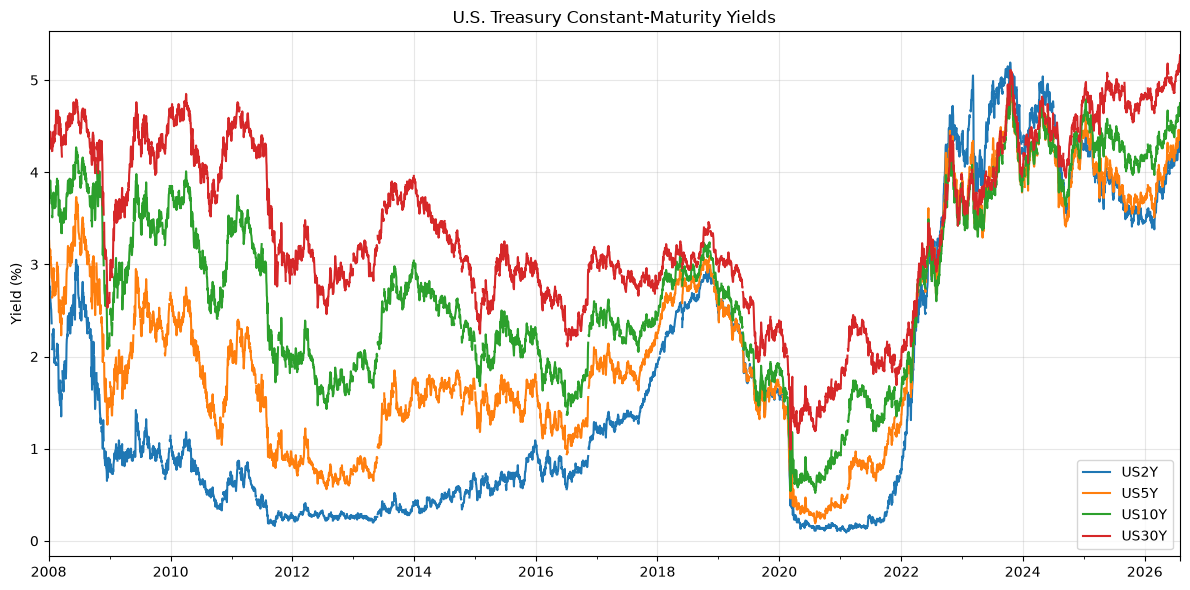

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

rates_daily[
    ["US2Y", "US5Y", "US10Y", "US30Y"]
].plot(ax=ax)

ax.set_title("U.S. Treasury Constant-Maturity Yields")
ax.set_xlabel("")
ax.set_ylabel("Yield (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

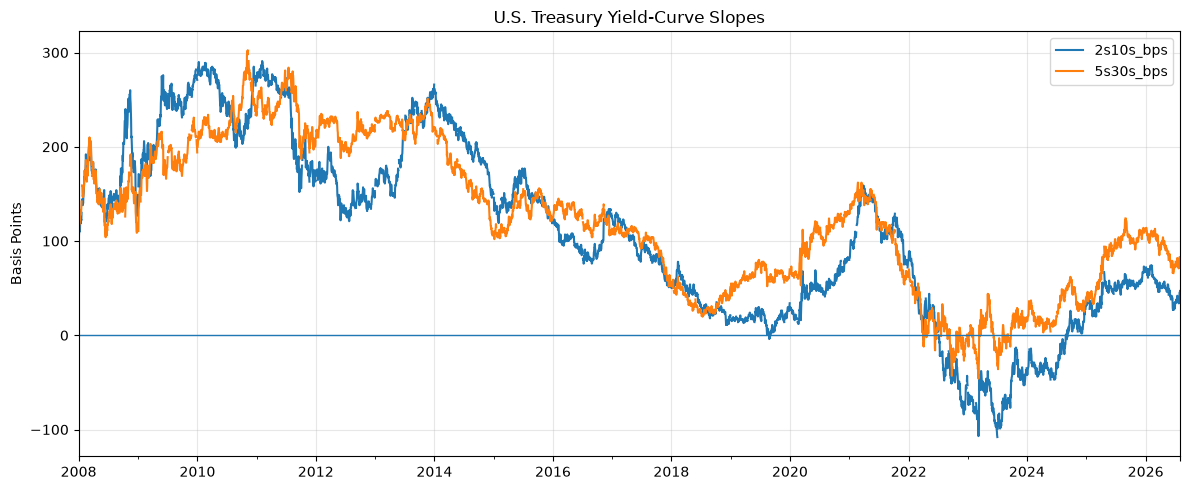

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

rates_daily[
    ["2s10s_bps", "5s30s_bps"]
].plot(ax=ax)

ax.axhline(0, linewidth=1)

ax.set_title("U.S. Treasury Yield-Curve Slopes")
ax.set_xlabel("")
ax.set_ylabel("Basis Points")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

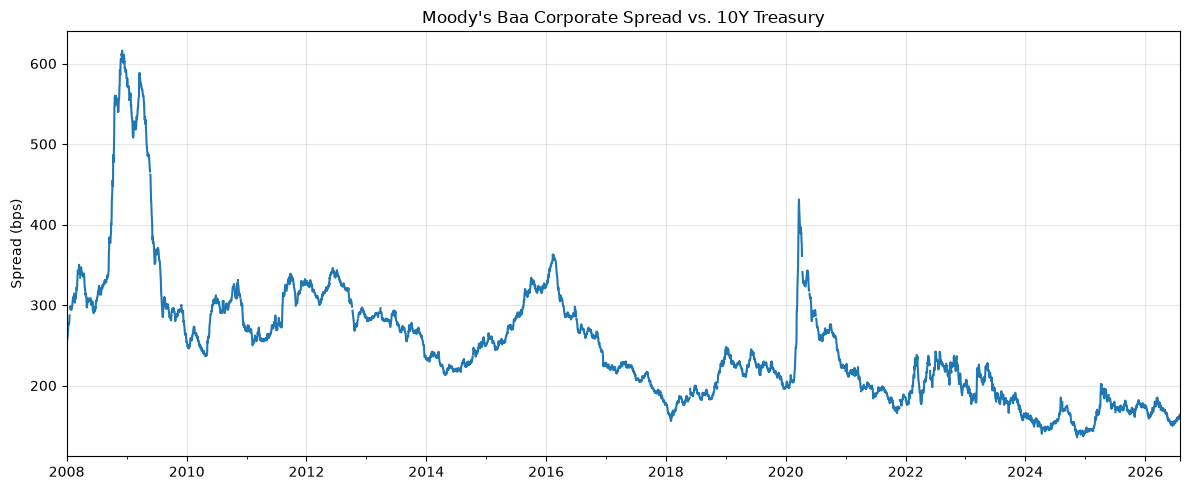

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

rates_daily["BAA10Y_bps"].plot(ax=ax)

ax.set_title("Moody's Baa Corporate Spread vs. 10Y Treasury")
ax.set_xlabel("")
ax.set_ylabel("Spread (bps)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Fixed-Income ETF Market Data

The investable universe consists of five U.S.-listed fixed-income ETFs representing different combinations of duration and credit exposure.

| ETF | Primary Role |
|---|---|
| SHY | Short-duration Treasury |
| IEF | Intermediate-duration Treasury |
| TLT | Long-duration Treasury |
| LQD | Investment-grade corporate credit |
| HYG | High-yield corporate credit |

Adjusted closing prices are used as a practical total-return proxy because distributions are economically important for bond ETF performance.

In [18]:
ETF_START_DATE = START_DATE

# yfinance end date is exclusive.
ETF_END_EXCLUSIVE = (
    pd.Timestamp(BACKTEST_END) + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")

print("ETF start:", ETF_START_DATE)
print("ETF end (exclusive):", ETF_END_EXCLUSIVE)

ETF start: 2008-01-01
ETF end (exclusive): 2026-08-01


In [19]:
etf_download = yf.download(
    tickers=ETF_TICKERS,
    start=ETF_START_DATE,
    end=ETF_END_EXCLUSIVE,
    auto_adjust=False,
    actions=False,
    progress=False,
    group_by="column",
)

In [20]:
print(type(etf_download.columns))
print(etf_download.columns)

etf_download.head()

<class 'pandas.MultiIndex'>
MultiIndex([('Adj Close', 'HYG'),
            ('Adj Close', 'IEF'),
            ('Adj Close', 'LQD'),
            ('Adj Close', 'SHY'),
            ('Adj Close', 'TLT'),
            (    'Close', 'HYG'),
            (    'Close', 'IEF'),
            (    'Close', 'LQD'),
            (    'Close', 'SHY'),
            (    'Close', 'TLT'),
            (     'High', 'HYG'),
            (     'High', 'IEF'),
            (     'High', 'LQD'),
            (     'High', 'SHY'),
            (     'High', 'TLT'),
            (      'Low', 'HYG'),
            (      'Low', 'IEF'),
            (      'Low', 'LQD'),
            (      'Low', 'SHY'),
            (      'Low', 'TLT'),
            (     'Open', 'HYG'),
            (     'Open', 'IEF'),
            (     'Open', 'LQD'),
            (     'Open', 'SHY'),
            (     'Open', 'TLT'),
            (   'Volume', 'HYG'),
            (   'Volume', 'IEF'),
            (   'Volume', 'LQD'),
            (   'Vol

Price       Adj Close                                                  Close  \
Ticker            HYG        IEF        LQD        SHY        TLT        HYG   
Date                                                                           
2008-01-02  31.520674  55.576889  51.636471  60.996212  53.587002  99.500000   
2008-01-03  31.460470  55.691067  51.466099  61.092556  53.513142  99.309998   
2008-01-04  31.425623  55.836987  51.889618  61.181442  53.524494  99.199997   
2008-01-07  31.238707  55.938385  51.826328  61.144390  53.757259  98.610001   
2008-01-08  31.058165  56.058933  51.728973  61.233276  53.694843  98.040001   

Price                                                    ...        Open  \
Ticker            IEF         LQD        SHY        TLT  ...         HYG   
Date                                                     ...               
2008-01-02  87.629997  106.080002  82.339996  94.379997  ...   99.559998   
2008-01-03  87.809998  105.730003  82.470001  94.250000  ...   99.599998   
2008-01-04  88.040001  106.599998  82.589996  94.269997  ...  100.010002   
2008-01-07  88.199997  106.470001  82.540001  94.680000  ...   99.489998   
2008-01-08  88.389999  106.269997  82.660004  94.570000  ...   99.489998   

Price                                                    Volume          \
Ticker            IEF         LQD        SHY        TLT     HYG     IEF   
Date                                                                      
2008-01-02  86.989998  105.610001  82.269997  93.250000   61800  564700   
2008-01-03  87.500000  105.360001  82.430000  94.000000   64800  198600   
2008-01-04  88.000000  106.290001  82.650002  94.500000   48600  368700   
2008-01-07  87.870003  106.550003  82.580002  94.180000  177200  341100   
2008-01-08  88.089996  106.540001  82.540001  94.440002   42100  293200   

Price                                 
Ticker         LQD      SHY      TLT  
Date                                  
2008-01-02  728300  1471100  2959600  
2008-01-03  151300   408400  1256700  
2008-01-04  135900   884700  2420200  
2008-01-07  148300   917400  1315500  
2008-01-08  127100  1154500  1604800  

[5 rows x 30 columns]

In [21]:
if isinstance(etf_download.columns, pd.MultiIndex):
    etf_prices = etf_download["Adj Close"].copy()
else:
    etf_prices = etf_download[["Adj Close"]].copy()

etf_prices = etf_prices.reindex(columns=ETF_TICKERS)

etf_prices.index = pd.to_datetime(etf_prices.index)

if getattr(etf_prices.index, "tz", None) is not None:
    etf_prices.index = etf_prices.index.tz_localize(None)

etf_prices.index.name = "Date"

etf_prices.head(10)

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-01-02,60.996212,55.576889,53.587002,51.636471,31.520674
2008-01-03,61.092556,55.691067,53.513142,51.466099,31.460470
2008-01-04,61.181442,55.836987,53.524494,51.889618,31.425623
2008-01-07,61.144390,55.938385,53.757259,51.826328,31.238707
2008-01-08,61.233276,56.058933,53.694843,51.728973,31.058165
2008-01-09,61.203686,55.970169,53.796978,51.621925,30.719196
2008-01-10,61.203686,55.817947,53.070259,51.471004,30.947269
2008-01-11,61.374027,56.173050,53.484745,51.845806,31.013790
2008-01-14,61.396267,56.198414,53.683487,51.631603,30.906080


In [22]:
print("Shape:")
print(etf_prices.shape)

print("\nColumns:")
print(etf_prices.columns.tolist())

print("\nDate range:")
print(etf_prices.index.min(), "to", etf_prices.index.max())

print("\nData types:")
print(etf_prices.dtypes)

print("\nMissing values:")
print(etf_prices.isna().sum())

print("\nFirst valid observation:")
for ticker in ETF_TICKERS:
    print(
        ticker,
        etf_prices[ticker].first_valid_index()
    )

Shape:
(4674, 5)

Columns:
['SHY', 'IEF', 'TLT', 'LQD', 'HYG']

Date range:
2008-01-02 00:00:00 to 2026-07-31 00:00:00

Data types:
Ticker
SHY    float64
IEF    float64
TLT    float64
LQD    float64
HYG    float64
dtype: object

Missing values:
Ticker
SHY    0
IEF    0
TLT    0
LQD    0
HYG    0
dtype: int64

First valid observation:
SHY 2008-01-02 00:00:00
IEF 2008-01-02 00:00:00
TLT 2008-01-02 00:00:00
LQD 2008-01-02 00:00:00
HYG 2008-01-02 00:00:00


In [23]:
assert etf_prices.index.is_monotonic_increasing, "ETF dates are not sorted."
assert etf_prices.index.is_unique, "Duplicate ETF dates found."

assert etf_prices.columns.tolist() == ETF_TICKERS, "Unexpected ETF columns."

for ticker in ETF_TICKERS:
    valid = etf_prices[ticker].dropna()

    assert len(valid) > 0, f"No valid data for {ticker}"
    assert (valid > 0).all(), f"Non-positive adjusted price detected for {ticker}"

print("Basic ETF validation passed.")

Basic ETF validation passed.


In [24]:
etf_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SHY,4674.0,70.428093,4.475310,60.996212,67.698648,69.218105,73.397867,81.758972
IEF,4674.0,82.446754,11.907560,55.399902,76.545378,84.110012,89.501053,105.318352
TLT,4674.0,87.572189,20.294121,51.408676,76.477905,86.180904,96.819548,142.127029
LQD,4674.0,83.331535,17.791410,41.282200,71.584799,85.300747,98.316458,111.937393
HYG,4674.0,52.391064,13.626579,21.559637,43.123451,53.269249,61.927452,79.484116


In [25]:
common_prices = etf_prices.dropna()

COMMON_START = common_prices.index.min()

print("First common ETF observation:", COMMON_START)

First common ETF observation: 2008-01-02 00:00:00


In [26]:
normalized_prices = (
    common_prices
    / common_prices.iloc[0]
    * 100
)

normalized_prices.head()

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2008-01-03,100.157951,100.205441,99.862168,99.670055,99.809003
2008-01-04,100.303675,100.467996,99.883353,100.490249,99.698449
2008-01-07,100.242930,100.650443,100.317722,100.367681,99.105453
2008-01-08,100.388654,100.867347,100.201246,100.179142,98.532680


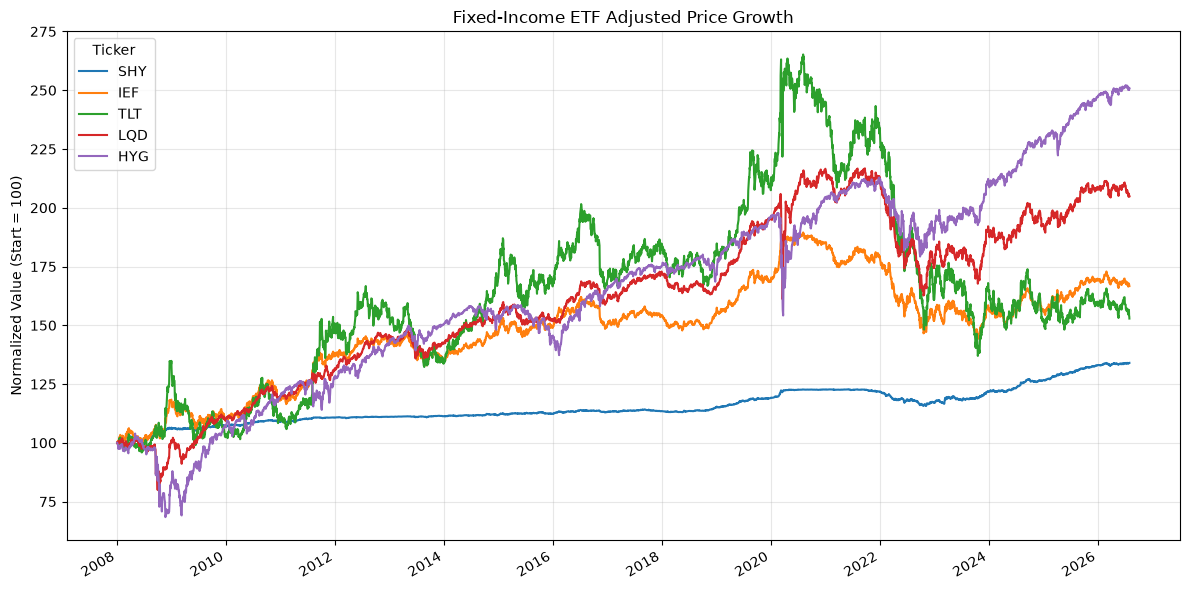

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

normalized_prices.plot(ax=ax)

ax.set_title("Fixed-Income ETF Adjusted Price Growth")
ax.set_xlabel("")
ax.set_ylabel("Normalized Value (Start = 100)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ETF Return Construction

Daily returns are calculated from adjusted closing prices.

Adjusted prices are used to capture the economic effect of distributions. These returns are treated as ETF total-return proxies rather than institutional bond-index total returns.

In [28]:
etf_returns_daily = etf_prices.pct_change(
    fill_method=None
)

etf_returns_daily.head(10)

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-01-02,NaN,NaN,NaN,NaN,NaN
2008-01-03,0.001580,0.002054,-0.001378,-0.003299,-0.001910
2008-01-04,0.001455,0.002620,0.000212,0.008229,-0.001108
2008-01-07,-0.000606,0.001816,0.004349,-0.001220,-0.005948
2008-01-08,0.001454,0.002155,-0.001161,-0.001878,-0.005779
2008-01-09,-0.000483,-0.001583,0.001902,-0.002069,-0.010914
2008-01-10,0.000000,-0.002720,-0.013509,-0.002924,0.007424
2008-01-11,0.002783,0.006362,0.007810,0.007282,0.002149
2008-01-14,0.000362,0.000452,0.003716,-0.004132,-0.003473


In [29]:
daily_return_summary = pd.DataFrame({
    "mean_daily_return": etf_returns_daily.mean(),
    "daily_volatility": etf_returns_daily.std(),
    "min_daily_return": etf_returns_daily.min(),
    "max_daily_return": etf_returns_daily.max(),
    "missing_returns": etf_returns_daily.isna().sum(),
})

daily_return_summary

,mean_daily_return,daily_volatility,min_daily_return,max_daily_return,missing_returns
Ticker,,,,,
SHY,0.000063,0.000941,-0.006567,0.009974,1
IEF,0.000119,0.004393,-0.025073,0.034262,1
TLT,0.000137,0.009625,-0.066683,0.075196,1
LQD,0.000169,0.005610,-0.091112,0.097677,1
HYG,0.000221,0.006886,-0.080975,0.122688,1


In [30]:
for ticker in ETF_TICKERS:
    print(f"\n{ticker}")
    
    largest = (
        etf_returns_daily[ticker]
        .dropna()
        .abs()
        .nlargest(5)
    )
    
    print(largest)


SHY
Date
2023-03-13    0.009974
2008-09-15    0.007094
2009-06-05    0.006567
2023-03-15    0.005875
2008-09-29    0.005755
Name: SHY, dtype: float64

IEF
Date
2009-03-18    0.034262
2020-03-16    0.026416
2020-03-20    0.025477
2020-03-17    0.025073
2022-09-28    0.022526
Name: IEF, dtype: float64

TLT
Date
2020-03-20    0.075196
2020-03-17    0.066683
2020-03-16    0.064766
2020-03-18    0.056413
2020-03-06    0.052044
Name: TLT, dtype: float64

LQD
Date
2008-09-30    0.097677
2008-09-29    0.091112
2020-03-23    0.073918
2008-09-16    0.063450
2008-10-13    0.055080
Name: LQD, dtype: float64

HYG
Date
2008-10-13    0.122688
2008-09-29    0.080975
2008-09-18    0.078889
2008-10-10    0.066704
2020-04-09    0.065459
Name: HYG, dtype: float64


In [31]:
annualized_volatility = (
    etf_returns_daily.std() * np.sqrt(252)
)

annualized_volatility.sort_values()

Ticker
SHY    0.014935
IEF    0.069740
LQD    0.089056
HYG    0.109317
TLT    0.152798
dtype: float64

## 7. Extreme-Return Validation

Large daily ETF returns are inspected explicitly before monthly aggregation.

Extreme observations are not removed simply because they are large. They are retained unless there is evidence of a price adjustment, download, or data-alignment error.

In [32]:
EXTREME_RETURN_THRESHOLD = 0.08

extreme_events = []

previous_prices = etf_prices.shift(1)

for ticker in ETF_TICKERS:
    extreme_mask = (
        etf_returns_daily[ticker].abs()
        >= EXTREME_RETURN_THRESHOLD
    )

    for date in etf_returns_daily.index[extreme_mask]:
        extreme_events.append({
            "Date": date,
            "Ticker": ticker,
            "Previous_Adjusted_Price": previous_prices.loc[date, ticker],
            "Current_Adjusted_Price": etf_prices.loc[date, ticker],
            "Daily_Return": etf_returns_daily.loc[date, ticker],
        })

extreme_events = pd.DataFrame(extreme_events)

if len(extreme_events) > 0:
    extreme_events = (
        extreme_events
        .sort_values(
            "Daily_Return",
            key=lambda x: x.abs(),
            ascending=False
        )
        .reset_index(drop=True)
    )

extreme_events

,Date,Ticker,Previous_Adjusted_Price,Current_Adjusted_Price,Daily_Return
0,2008-10-13,HYG,22.949446,25.765066,0.122688
1,2008-09-30,LQD,41.282200,45.314537,0.097677
2,2008-09-29,LQD,45.420559,41.282200,-0.091112
3,2008-09-29,HYG,28.787741,26.456665,-0.080975


In [33]:
if len(extreme_events) > 0:
    sample_event = extreme_events.iloc[0]

    sample_date = sample_event["Date"]
    sample_ticker = sample_event["Ticker"]

    previous_price = sample_event["Previous_Adjusted_Price"]
    current_price = sample_event["Current_Adjusted_Price"]

    manual_return = (
        current_price / previous_price - 1
    )

    stored_return = sample_event["Daily_Return"]

    print("Date   :", sample_date)
    print("Ticker :", sample_ticker)

    print("\nPrevious adjusted price :", previous_price)
    print("Current adjusted price  :", current_price)

    print("\nStored return :", stored_return)
    print("Manual return :", manual_return)

    assert np.isclose(
        stored_return,
        manual_return
    )

    print("\nExtreme-return calculation passed.")

Date   : 2008-10-13 00:00:00
Ticker : HYG

Previous adjusted price : 22.949445724487305
Current adjusted price  : 25.765066146850586

Stored return : 0.12268794881433598
Manual return : 0.12268794881433598

Extreme-return calculation passed.


## 8. Month-End Research Panel

Daily market observations are converted into a monthly research panel.

- Market information is sampled using the latest available observation within each calendar month.
- ETF monthly returns are calculated from consecutive month-end adjusted prices.
- Calendar month-end labels are used for alignment, while actual source observation dates are retained separately for validation.
- No future information is introduced at this stage.

In [34]:
RATE_FEATURES = [
    "US2Y",
    "US5Y",
    "US10Y",
    "US30Y",
    "2s10s_bps",
    "5s30s_bps",
    "BAA10Y",
    "BAA10Y_bps",
]

rates_monthly = (
    rates_daily[RATE_FEATURES]
    .resample("ME")
    .last()
)

rates_monthly.head()

,US2Y,US5Y,US10Y,US30Y,2s10s_bps,5s30s_bps,BAA10Y,BAA10Y_bps
Date,,,,,,,,
2008-01-31,2.17,2.82,3.67,4.35,150.0,153.0,2.96,296.0
2008-02-29,1.65,2.50,3.53,4.41,188.0,191.0,3.22,322.0
2008-03-31,1.62,2.46,3.45,4.30,183.0,184.0,3.45,345.0
2008-04-30,2.29,3.03,3.77,4.49,148.0,146.0,3.10,310.0
2008-05-31,2.66,3.41,4.06,4.72,140.0,131.0,3.00,300.0


In [35]:
rates_monthly.tail(12)

,US2Y,US5Y,US10Y,US30Y,2s10s_bps,5s30s_bps,BAA10Y,BAA10Y_bps
Date,,,,,,,,
2025-08-31,3.59,3.68,4.23,4.92,64.0,124.0,1.80,180.0
2025-09-30,3.60,3.74,4.16,4.73,56.0,99.0,1.67,167.0
2025-10-31,3.60,3.71,4.11,4.67,51.0,96.0,1.69,169.0
2025-11-30,3.47,3.59,4.02,4.67,55.0,108.0,1.78,178.0
2025-12-31,3.47,3.73,4.18,4.84,71.0,111.0,1.72,172.0
2026-01-31,3.52,3.79,4.26,4.87,74.0,108.0,1.62,162.0
2026-02-28,3.38,3.51,3.97,4.64,59.0,113.0,1.80,180.0
2026-03-31,3.79,3.92,4.30,4.88,51.0,96.0,1.79,179.0
2026-04-30,3.88,4.02,4.40,4.98,52.0,96.0,1.70,170.0


In [36]:
us10y_obs_date = (
    rates_daily["US10Y"]
    .resample("ME")
    .apply(lambda x: x.last_valid_index())
    .rename("US10Y_obs_date")
)

baa_obs_date = (
    rates_daily["BAA10Y"]
    .resample("ME")
    .apply(lambda x: x.last_valid_index())
    .rename("BAA10Y_obs_date")
)

rate_observation_dates = pd.concat(
    [
        us10y_obs_date,
        baa_obs_date,
    ],
    axis=1
)

rate_observation_dates.tail(12)

,US10Y_obs_date,BAA10Y_obs_date
Date,,
2025-08-31,2025-08-29,2025-08-29
2025-09-30,2025-09-30,2025-09-30
2025-10-31,2025-10-31,2025-10-31
2025-11-30,2025-11-28,2025-11-28
2025-12-31,2025-12-31,2025-12-31
2026-01-31,2026-01-30,2026-01-30
2026-02-28,2026-02-27,2026-02-27
2026-03-31,2026-03-31,2026-03-31
2026-04-30,2026-04-30,2026-04-30


### Observation-Date Convention

Monthly rows are labeled by calendar month-end for consistent alignment.

Because calendar month-end may fall on a weekend or market holiday, the actual last available observation date can precede the month-end label. Source observation dates for the primary rate and credit signals are therefore retained explicitly.

This distinction will later help verify that month-end signals are applied only to subsequent portfolio returns.

In [37]:
etf_prices_monthly = (
    etf_prices
    .resample("ME")
    .last()
)

etf_prices_monthly.head()

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-01-31,61.892597,57.035625,53.933300,52.342274,31.324257
2008-02-29,62.532078,57.742439,53.687721,51.972607,30.738672
2008-03-31,62.690624,58.514652,54.836002,51.662254,31.029505
2008-04-30,62.165565,57.100121,53.472652,52.305233,32.083557
2008-05-31,61.950409,56.085175,52.035160,51.151871,31.920414


In [38]:
etf_last_trade_date = (
    pd.Series(
        etf_prices.index,
        index=etf_prices.index
    )
    .resample("ME")
    .max()
    .rename("ETF_obs_date")
)

etf_last_trade_date.tail(12)

Date
2025-08-31   2025-08-29
2025-09-30   2025-09-30
2025-10-31   2025-10-31
2025-11-30   2025-11-28
2025-12-31   2025-12-31
2026-01-31   2026-01-30
2026-02-28   2026-02-27
2026-03-31   2026-03-31
2026-04-30   2026-04-30
2026-05-31   2026-05-29
2026-06-30   2026-06-30
2026-07-31   2026-07-31
Freq: ME, Name: ETF_obs_date, dtype: datetime64[s]

In [39]:
etf_returns_monthly = (
    etf_prices_monthly
    .pct_change(fill_method=None)
)

etf_returns_monthly.head()

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2008-01-31,NaN,NaN,NaN,NaN,NaN
2008-02-29,0.010332,0.012392,-0.004553,-0.007062,-0.018694
2008-03-31,0.002535,0.013373,0.021388,-0.005971,0.009461
2008-04-30,-0.008375,-0.024174,-0.024862,0.012446,0.033969
2008-05-31,-0.003461,-0.017775,-0.026883,-0.022051,-0.005085


In [40]:
etf_returns_monthly.tail(12)

Ticker,SHY,IEF,TLT,LQD,HYG
Date,,,,,
2025-08-31,0.008875,0.016482,0.000127,0.010436,0.011053
2025-09-30,0.002877,0.006511,0.035910,0.018772,0.008860
2025-10-31,0.003337,0.007113,0.013811,0.001495,-0.000111
2025-11-30,0.004388,0.009881,0.002723,0.009312,0.007464
2025-12-31,0.002947,-0.007612,-0.026586,-0.007375,0.004926
2026-01-31,0.002053,-0.002288,-0.000345,0.003449,0.006077
2026-02-28,0.005318,0.024700,0.046338,0.013780,-0.000012
2026-03-31,-0.004665,-0.023202,-0.042300,-0.020728,-0.009536
2026-04-30,0.001907,-0.001503,-0.008396,0.002819,0.015207


In [41]:
ticker_to_check = "TLT"

previous_month_price = (
    etf_prices_monthly[ticker_to_check].iloc[-2]
)

current_month_price = (
    etf_prices_monthly[ticker_to_check].iloc[-1]
)

manual_monthly_return = (
    current_month_price / previous_month_price - 1
)

stored_monthly_return = (
    etf_returns_monthly[ticker_to_check].iloc[-1]
)

print("Ticker:", ticker_to_check)

print("\nPrevious month-end price:")
print(previous_month_price)

print("\nCurrent month-end price:")
print(current_month_price)

print("\nStored monthly return:")
print(stored_monthly_return)

print("\nManual monthly return:")
print(manual_monthly_return)

assert np.isclose(
    stored_monthly_return,
    manual_monthly_return
)

print("\nMonthly return calculation passed.")

Ticker: TLT

Previous month-end price:
85.75653839111328

Current month-end price:
81.91999816894531

Stored monthly return:
-0.04473758262804994

Manual monthly return:
-0.04473758262804994

Monthly return calculation passed.


In [42]:
monthly_panel = rates_monthly.copy()

monthly_panel = monthly_panel.join(
    rate_observation_dates,
    how="left"
)

monthly_panel = monthly_panel.join(
    etf_last_trade_date,
    how="left"
)

monthly_panel = monthly_panel.join(
    etf_prices_monthly.add_suffix("_price"),
    how="left"
)

monthly_panel = monthly_panel.join(
    etf_returns_monthly.add_suffix("_ret"),
    how="left"
)

monthly_panel.head()

,US2Y,US5Y,US10Y,US30Y,2s10s_bps,5s30s_bps,BAA10Y,BAA10Y_bps,US10Y_obs_date,BAA10Y_obs_date,...,SHY_price,IEF_price,TLT_price,LQD_price,HYG_price,SHY_ret,IEF_ret,TLT_ret,LQD_ret,HYG_ret
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-31,2.17,2.82,3.67,4.35,150.0,153.0,2.96,296.0,2008-01-31,2008-01-31,...,61.892597,57.035625,53.933300,52.342274,31.324257,NaN,NaN,NaN,NaN,NaN
2008-02-29,1.65,2.50,3.53,4.41,188.0,191.0,3.22,322.0,2008-02-29,2008-02-29,...,62.532078,57.742439,53.687721,51.972607,30.738672,0.010332,0.012392,-0.004553,-0.007062,-0.018694
2008-03-31,1.62,2.46,3.45,4.30,183.0,184.0,3.45,345.0,2008-03-31,2008-03-31,...,62.690624,58.514652,54.836002,51.662254,31.029505,0.002535,0.013373,0.021388,-0.005971,0.009461
2008-04-30,2.29,3.03,3.77,4.49,148.0,146.0,3.10,310.0,2008-04-30,2008-04-30,...,62.165565,57.100121,53.472652,52.305233,32.083557,-0.008375,-0.024174,-0.024862,0.012446,0.033969
2008-05-31,2.66,3.41,4.06,4.72,140.0,131.0,3.00,300.0,2008-05-30,2008-05-30,...,61.950409,56.085175,52.035160,51.151871,31.920414,-0.003461,-0.017775,-0.026883,-0.022051,-0.005085


In [43]:
print("Shape:")
print(monthly_panel.shape)

print("\nDate range:")
print(
    monthly_panel.index.min(),
    "to",
    monthly_panel.index.max()
)

print("\nNumber of months:")
print(len(monthly_panel))

print("\nColumns:")
for col in monthly_panel.columns:
    print(col)

Shape:
(223, 21)

Date range:
2008-01-31 00:00:00 to 2026-07-31 00:00:00

Number of months:
223

Columns:
US2Y
US5Y
US10Y
US30Y
2s10s_bps
5s30s_bps
BAA10Y
BAA10Y_bps
US10Y_obs_date
BAA10Y_obs_date
ETF_obs_date
SHY_price
IEF_price
TLT_price
LQD_price
HYG_price
SHY_ret
IEF_ret
TLT_ret
LQD_ret
HYG_ret


In [44]:
monthly_panel.isna().sum()

US2Y               0
US5Y               0
US10Y              0
US30Y              0
2s10s_bps          0
5s30s_bps          0
BAA10Y             0
BAA10Y_bps         0
US10Y_obs_date     0
BAA10Y_obs_date    0
ETF_obs_date       0
SHY_price          0
IEF_price          0
TLT_price          0
LQD_price          0
HYG_price          0
SHY_ret            1
IEF_ret            1
TLT_ret            1
LQD_ret            1
HYG_ret            1
dtype: int64

In [45]:
monthly_panel["US10Y_obs_lag_days"] = (
    monthly_panel.index
    - monthly_panel["US10Y_obs_date"]
).dt.days

monthly_panel["BAA10Y_obs_lag_days"] = (
    monthly_panel.index
    - monthly_panel["BAA10Y_obs_date"]
).dt.days

monthly_panel["ETF_obs_lag_days"] = (
    monthly_panel.index
    - monthly_panel["ETF_obs_date"]
).dt.days

monthly_panel[
    [
        "US10Y_obs_date",
        "US10Y_obs_lag_days",
        "BAA10Y_obs_date",
        "BAA10Y_obs_lag_days",
        "ETF_obs_date",
        "ETF_obs_lag_days",
    ]
].tail(12)

,US10Y_obs_date,US10Y_obs_lag_days,BAA10Y_obs_date,BAA10Y_obs_lag_days,ETF_obs_date,ETF_obs_lag_days
Date,,,,,,
2025-08-31,2025-08-29,2,2025-08-29,2,2025-08-29,2
2025-09-30,2025-09-30,0,2025-09-30,0,2025-09-30,0
2025-10-31,2025-10-31,0,2025-10-31,0,2025-10-31,0
2025-11-30,2025-11-28,2,2025-11-28,2,2025-11-28,2
2025-12-31,2025-12-31,0,2025-12-31,0,2025-12-31,0
2026-01-31,2026-01-30,1,2026-01-30,1,2026-01-30,1
2026-02-28,2026-02-27,1,2026-02-27,1,2026-02-27,1
2026-03-31,2026-03-31,0,2026-03-31,0,2026-03-31,0
2026-04-30,2026-04-30,0,2026-04-30,0,2026-04-30,0


In [46]:
lag_columns = [
    "US10Y_obs_lag_days",
    "BAA10Y_obs_lag_days",
    "ETF_obs_lag_days",
]

monthly_panel[lag_columns].describe()

,US10Y_obs_lag_days,BAA10Y_obs_lag_days,ETF_obs_lag_days
count,223.000000,223.000000,223.000000
mean,0.475336,0.479821,0.475336
std,0.798688,0.798814,0.798688
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,3.000000,3.000000,3.000000


In [47]:
for col in lag_columns:
    assert (monthly_panel[col] >= 0).all(), (
        f"Future observation detected in {col}"
    )

    assert (monthly_panel[col] <= 7).all(), (
        f"Suspiciously stale month-end observation in {col}"
    )

print("Month-end observation-date validation passed.")

Month-end observation-date validation passed.


In [48]:
RATE_LEVEL_COLUMNS = [
    "US2Y",
    "US5Y",
    "US10Y",
    "US30Y",
    "2s10s_bps",
    "5s30s_bps",
    "BAA10Y",
    "BAA10Y_bps",
]

ETF_PRICE_COLUMNS = [
    f"{ticker}_price"
    for ticker in ETF_TICKERS
]

ETF_RETURN_COLUMNS = [
    f"{ticker}_ret"
    for ticker in ETF_TICKERS
]

assert monthly_panel.index.is_monotonic_increasing
assert monthly_panel.index.is_unique

assert monthly_panel.index.min() == pd.Timestamp("2008-01-31")
assert monthly_panel.index.max() == pd.Timestamp("2026-07-31")

assert len(monthly_panel) == 223

assert (
    monthly_panel[RATE_LEVEL_COLUMNS]
    .notna()
    .all()
    .all()
)

assert (
    monthly_panel[ETF_PRICE_COLUMNS]
    .notna()
    .all()
    .all()
)

assert (
    monthly_panel[
        ETF_RETURN_COLUMNS
    ].iloc[0].isna().all()
)

assert (
    monthly_panel[
        ETF_RETURN_COLUMNS
    ].iloc[1:].notna().all().all()
)

print("Monthly research panel validation passed.")

Monthly research panel validation passed.


In [49]:
monthly_panel[
    [
        "US2Y",
        "US10Y",
        "2s10s_bps",
        "BAA10Y_bps",
        "SHY_ret",
        "IEF_ret",
        "TLT_ret",
        "LQD_ret",
        "HYG_ret",
    ]
].tail(6)

,US2Y,US10Y,2s10s_bps,BAA10Y_bps,SHY_ret,IEF_ret,TLT_ret,LQD_ret,HYG_ret
Date,,,,,,,,,
2026-02-28,3.38,3.97,59.0,180.0,0.005318,0.024700,0.046338,0.013780,-0.000012
2026-03-31,3.79,4.30,51.0,179.0,-0.004665,-0.023202,-0.042300,-0.020728,-0.009536
2026-04-30,3.88,4.40,52.0,170.0,0.001907,-0.001503,-0.008396,0.002819,0.015207
2026-05-31,3.98,4.45,47.0,157.0,0.000766,-0.000190,0.005334,0.008624,0.004365
2026-06-30,4.14,4.44,30.0,153.0,0.000646,0.002512,0.011659,0.001129,0.000863
2026-07-31,4.28,4.75,47.0,163.0,0.001563,-0.013887,-0.044738,-0.022431,-0.001520


In [50]:
fred_raw.to_csv(
    RAW_DIR / "fred_rates_credit_daily.csv"
)

etf_prices.to_csv(
    RAW_DIR / "etf_adjusted_prices_daily.csv"
)

etf_returns_daily.to_csv(
    PROCESSED_DIR / "etf_returns_daily.csv"
)

monthly_panel.to_csv(
    PROCESSED_DIR / "fixed_income_monthly_panel.csv"
)

print("Files saved successfully.")

print("\nRaw:")
print(RAW_DIR / "fred_rates_credit_daily.csv")
print(RAW_DIR / "etf_adjusted_prices_daily.csv")

print("\nProcessed:")
print(PROCESSED_DIR / "etf_returns_daily.csv")
print(PROCESSED_DIR / "fixed_income_monthly_panel.csv")

Files saved successfully.

Raw:
c:\Users\minha\Desktop\global-fixed-income-strategy\data\raw\fred_rates_credit_daily.csv
c:\Users\minha\Desktop\global-fixed-income-strategy\data\raw\etf_adjusted_prices_daily.csv

Processed:
c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed\etf_returns_daily.csv
c:\Users\minha\Desktop\global-fixed-income-strategy\data\processed\fixed_income_monthly_panel.csv


In [51]:
files_to_check = [
    RAW_DIR / "fred_rates_credit_daily.csv",
    RAW_DIR / "etf_adjusted_prices_daily.csv",
    PROCESSED_DIR / "etf_returns_daily.csv",
    PROCESSED_DIR / "fixed_income_monthly_panel.csv",
]

for file_path in files_to_check:
    print(
        file_path.name,
        "->",
        file_path.exists()
    )

fred_rates_credit_daily.csv -> True
etf_adjusted_prices_daily.csv -> True
etf_returns_daily.csv -> True
fixed_income_monthly_panel.csv -> True


In [52]:
print("=" * 60)
print("STEP 2 — FIXED INCOME DATA PIPELINE COMPLETE")
print("=" * 60)

print(
    f"\nDaily rates sample : "
    f"{rates_daily.index.min().date()} "
    f"→ {rates_daily.index.max().date()}"
)

print(
    f"Daily ETF sample   : "
    f"{etf_prices.index.min().date()} "
    f"→ {etf_prices.index.max().date()}"
)

print(
    f"Monthly panel      : "
    f"{monthly_panel.index.min().date()} "
    f"→ {monthly_panel.index.max().date()}"
)

print(
    f"Monthly observations: {len(monthly_panel)}"
)

print(
    f"ETF universe: {', '.join(ETF_TICKERS)}"
)

print("\nPrimary future signals:")
print("- 3M change in US10Y")
print("- 3M change in BAA10Y")

print("\nCurve interpretation:")
print("- 2s10s")
print("- 5s30s")

print("\nNo strategy rules or performance optimization applied.")

STEP 2 — FIXED INCOME DATA PIPELINE COMPLETE

Daily rates sample : 2008-01-01 → 2026-07-31
Daily ETF sample   : 2008-01-02 → 2026-07-31
Monthly panel      : 2008-01-31 → 2026-07-31
Monthly observations: 223
ETF universe: SHY, IEF, TLT, LQD, HYG

Primary future signals:
- 3M change in US10Y
- 3M change in BAA10Y

Curve interpretation:
- 2s10s
- 5s30s

No strategy rules or performance optimization applied.


## Step 2 Conclusion

The fixed-income research dataset has been constructed and validated.

The resulting monthly panel contains:

- U.S. Treasury rates across the 2Y, 5Y, 10Y, and 30Y maturities
- 2s10s and 5s30s yield-curve slopes
- Baa corporate credit spread
- Adjusted prices and monthly returns for SHY, IEF, TLT, LQD, and HYG
- Actual source observation dates for month-end validation

No portfolio signal, allocation rule, or backtest parameter has been selected based on subsequent performance.

The next stage defines the pre-specified rate and credit regimes.